# Real-time Communication

In [1]:
import networkx as nx 
from dataXplorer import JupyterClient
from dataXplorer import AnalysisToolkit, SessionManager, TextureGenerator, ProjectFileManager, VisualizerSyncer

### Clients enter Space 

In [2]:
# run backend (server) using buildandrun powershell script
client = JupyterClient()

#client.disconnect()

✅ Connected to /main


✅ Connected to /main
✅ Connected to /main


### Create new Project  (if project is not in list)

In [27]:
import pandas as pd

edge_df = pd.read_csv(
    'temp-files/PPI_joel/human_ppi.tsv',
    sep = '\t',
    #compression = 'gzip',
    header = None,
    names = ['A', 'B']
)
edges = []
for _, row in edge_df.iterrows():
    edges.append(
        (row.A, row.B)
    )

G = nx.Graph()
G.add_edges_from(edges)

# use only the largest connected component
def largest_connected_component(G):
    largest_cc = max(nx.connected_components(G), key=len)
    return largest_cc

# use only the largest connected component
lcc_nodes = largest_connected_component(G)
G = nx.induced_subgraph(G, lcc_nodes)

KeyboardInterrupt: 

In [ ]:
G.nodes()

nodenames = list(G.nodes())

In [ ]:
#number of nodes
n_nodes = G.number_of_nodes()
print(f"Number of nodes in the PPI network: {n_nodes}")
#number of edges
n_edges = G.number_of_edges()
print(f"Number of edges in the PPI network: {n_edges}")


Number of nodes in the PPI network: 18176
Number of edges in the PPI network: 476727


In [ ]:
G.graph['projectname'] = "PPI_joel_daniel_aryan"
G.graph['info'] = "."

#posG = nx.spring_layout(G, dim=3)
posG = nx.random_layout(G, dim=3, seed=42)
posG_3D = dict(zip(G.nodes(),[i.tolist() for i in posG.values()])) # 3D positions
nx.set_node_attributes(G, posG_3D, 'pos')

blueblue = "#0739ff"
d_nodecolors_hex = dict(zip(G.nodes(),[blueblue]*len(G.nodes()))) 
nx.set_node_attributes(G, d_nodecolors_hex, 'nodecolor')

lightblue = "#001d91"
l_linkcolors_hex = lightblue
nx.set_edge_attributes(G, l_linkcolors_hex, 'linkcolor')

import nx2json as nx2j 
nx2j.create_project(G)

Successfully created the directory static/projects/PPI_joel_daniel_aryan 
PROGRESS: loaded graph JSON...
PROGRESS: stored graph data...
PROGRESS: stored layouts...
PROGRESS: stored node info...
PROGRESS: made node position textures...
PROGRESS: made textures for node colors...
PROGRESS: made textures for links...
PROGRESS: made textures for linkcolors...
PROGRESS: writing json files for project and nodes...
Project created successfully.


### Access Project list and select one by ID

In [3]:
# see if new project is in projectlist
import GlobalData as GD

allprojects_updated = []
for i, proj in enumerate(GD.listProjects()):
    allprojects_updated.append((i,proj))
allprojects_updated

[(0, '123_test'),
 (1, 'CDK5'),
 (2, 'CircLadderGraph-xsmall'),
 (3, 'diffusion'),
 (4, 'JSON_autocore'),
 (5, 'JSON_barbellgraph'),
 (6, 'JSON_Zachary'),
 (7, 'Microplastics_HumanHealth'),
 (8, 'Pesticides_HumanHealth'),
 (9, 'PG_NEW'),
 (10, 'Powergrid_Europe'),
 (11, 'PPI_brain_infarction'),
 (12, 'PPI_joel'),
 (13, 'PPI_joel_2'),
 (14, 'PPI_joel_3'),
 (15, 'PPI_joel_daniel_aryan'),
 (16, 'PPI_networkcartoGRAPHs'),
 (17, 'Realtime-project'),
 (18, 'Sphere_Torus'),
 (19, 'Teapot'),
 (20, 'test'),
 (21, 'TheMandelbulb_edges'),
 (22, 'XX')]

In [4]:
# select a project to work with
sel_id = 15
sel_name = allprojects_updated[sel_id][1]

# load the project data
session = SessionManager(sel_id, sel_name, client)
session.load_graph_from_project()
session.reload_project()

# initialize 
file_mgr = ProjectFileManager(session)
tex_gen = TextureGenerator(session)
syncer = VisualizerSyncer(session)

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


In [5]:
G = session.load_graph_from_project()

# get nodenames from node attributes
nodenames_session = [data.get("name") for _, data in G.nodes(data=True)]
nodenames_session = [name for name in nodenames_session if name is not None]

# rename nodes back to original names
mapping = dict(zip(G.nodes(), nodenames_session))
G = nx.relabel_nodes(G, mapping)
G.nodes()

Session Graph loaded from project folder. 
Project name:  PPI_joel_daniel_aryan
Data: Nodes: 18176 Links: 476727


NodeView(('CIC', 'GTPBP3', 'KLF5', 'TRIM22', 'SOX15', 'ELF4', 'ELK3', 'SETD2', 'SOX6', 'YWHAQ', 'FOXQ1', 'SOX5', 'PAX7', 'SP7', 'HNF4A', 'KLHL22', 'ERG', 'S100P', 'TEAD1', 'PICK1', 'NFIX', 'PAX6', 'SOX17', 'TLX2', 'IRF8', 'RAVER1', 'GABPB1', 'NFIC', 'YWHAB', 'GATA2', 'LHX3', 'FOS', 'EN1', 'MAD2L1', 'KLF3', 'TBXT', 'TLX3', 'PAX9', 'NFYC', 'TBR1', 'SEC62', 'LHX6', 'CENPJ', 'PRDM1', 'HNF1A', 'SOX9', 'PYCR2', 'TLX1', 'CSNK2B', 'YWHAZ', 'RAD50', 'VSX1', 'IRF4', 'LHX4', 'PAX8', 'ZBTB18', 'GATA3', 'FOXL1', 'PLK1', 'YWHAE', 'MYB', 'ESR1', 'POLR1H', 'GOLGA2', 'PAX2', 'AR', 'GCM1', 'LHX2', 'FEV', 'SOX2', 'FOXK2', 'YWHAG', 'SOX10', 'HNF1B', 'ATXN1', 'KLF12', 'KLF15', 'NFIA', 'EYA2', 'YWHAH', 'NFIB', 'KLF8', 'PRPF3', 'PPP1R18', 'ETFRF1', 'RASL10B', 'MRPL21', 'DPPA4', 'SERTAD3', 'GPR45', 'MBD3L1', 'GNE', 'TARDBP', 'PYCR1', 'AGR2', 'RALY', 'PIKFYVE', 'MEOX2', 'MESD', 'INCA1', 'BEND7', 'PTAFR', 'MGST3', 'RCN1', 'COPS5', 'YARS2', 'SPINT2', 'IMMP2L', 'ZNF774', 'CAPN3', 'RAMP2', 'PDK1', 'KLK14', 'SINHCA

### Manipulate node colors / positions / link colors 

In [6]:
# initialize analysis toolkit
tools = AnalysisToolkit(session, tex_gen, syncer, file_mgr)

In [7]:
import pandas as pd
# read gene list from csv
symbol_pep_3 = pd.read_csv('temp-files/PPI_joel/symbol_pep_3.csv', header=None)[0].tolist()
symbol_pep_11 = pd.read_csv('temp-files/PPI_joel/symbol_pep_11.csv', header=None)[0].tolist()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

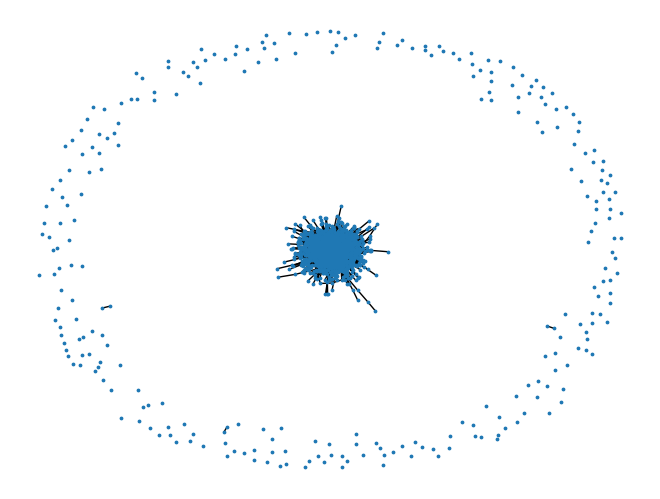

In [9]:
nodelist = symbol_pep_3
#temp_nodelist = ['node0', 'node1', 'node2', 'node3', 'node4', 'node5', 'node6', 'node7', 'node8']

tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, color = (255,0,0,200))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

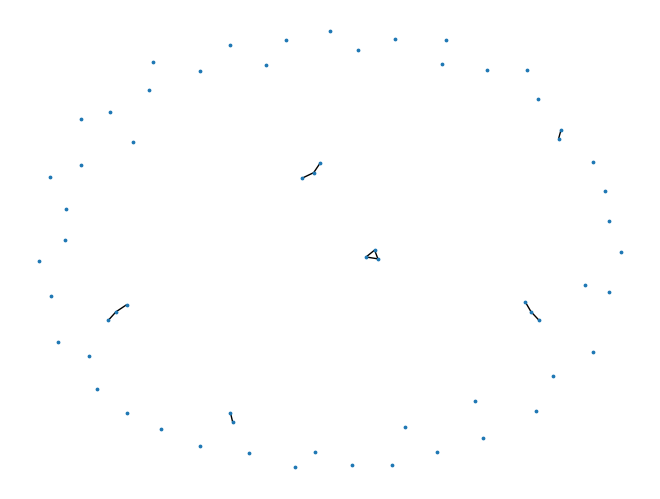

In [10]:
nodelist = symbol_pep_11
tools.extract_and_highlight_subnetwork_from_nodelist(nodelist, relayout=False, color = (255,0,0,200))

### 04 : relayout whole network  based on node annotations 

### 05 :  ADD SELECTIONS (realtime "landmarks") (VR-client)

In [ ]:
# SCENARIO 
# jupyter receive selected nodes from VR 
# 

# ---  SNIPPETS --- 

# OLD manual texture generation

### MODIFY PROJECT REAL TIME
- node colors 
- link colors
- node positions

In [ ]:
# change linkcolors 

visible_links = list(G.edges())#[::10]
print(len(visible_links))
print(visible_links[:10])

linkcolors = [(255,0,255,100)]

new_texture_name = 'teapot_showALLlinks'

In [ ]:
from PIL import Image

hight = 64 * (int((len(list(G.edges()))) / 32768) + 1)
path = 'static/projects/' + sel_name 
texc = [(0,0,0,10)] * 512 * hight  
new_imgc = Image.new('RGBA', (512, hight))

link_rgba = [(l,c) for l in visible_links for c in linkcolors]
    
edge_to_index = {tuple(edge): i for i, edge in enumerate(G.edges())}
for l, c in link_rgba:
    if tuple(l) in edge_to_index:
        i = edge_to_index[tuple(l)]
        texc[i]  = (int(c[0]),int(c[1]),int(c[2]),int(c[3]))

new_imgc.putdata(texc)
pathRGB = path + '/linksRGB/' + new_texture_name +'.png' 
new_imgc.save(pathRGB, "PNG")


In [ ]:
# SAVE TO PERMAMENT FILE STRUCTURE

# add to pfile channel 
import json
pfile = path + '/pfile.json'
with open(pfile) as f:
    data = json.load(f)

    # if not exists add
    if new_texture_name not in data['linksRGB']:
         data['linksRGB'].append(new_texture_name)
    
    # also add to other channels
    if new_texture_name not in data['layouts']:
        data['layouts'].append(new_texture_name)
    if new_texture_name not in data['layoutsRGB']:
        data['layoutsRGB'].append(new_texture_name)

with open(pfile, 'w') as f:
    json.dump(data, f, indent=4)


# add textures to other channels for file number consistency
import shutil
import os

# read all files in a folders
current_layouts = os.listdir(path + '/layouts')
current_layoutsrgb = os.listdir(path + '/layoutsRGB')
current_layoutsl = os.listdir(path + '/layoutsl')
print("Current layouts: ", current_layouts)

# copy one of the files via index and save as new name = same as texture generated 
shutil.copy(path + "/layouts/" + current_layouts[0], path + "/layouts/" + new_texture_name + ".bmp")
shutil.copy(path + "/layoutsRGB/" + current_layoutsrgb[0], path + "/layoutsRGB/" + new_texture_name + ".png")
shutil.copy(path + "/layoutsl/" + current_layoutsl[0], path + "/layoutsl/" + new_texture_name + "l.bmp")

In [ ]:
# UPDATE TEXTURE AND SEND TO FRONTEND 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': "updateTempTex",
    'id': 'linksRGBDD',
    'textures':[{"channel": "linkRGB", 
                  'path': "static/projects/"+ sel_name  + "/linksRGB/" + new_texture_name + ".png"}]
}, namespace='/main')

In [ ]:
# RELOAD CURRENT PROJECT 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')


### REAL-TIME LAYOUTS

In [ ]:
# MODIFY NODE POSITION 

new_layout_name = "C_temp"


# FUNCTION FOR NODE XYZ texture
hight = 128 * (int((len(G.nodes())) / 16384) + 1)
size = 128 * hight 
path = 'static/projects/' + sel_name 
    
texh = [(0,0,0)] * size
texl = [(0,0,0)] * size

# add layout here !!!!!!!!!
# the below part is dummy data for testing
nodes_pos = nx.get_node_attributes(G, 'pos') 
new_node_pos = {k: (v[0], v[2], v[1]) for k, v in nodes_pos.items()}

for i in range(len(new_node_pos)):

    x = int(float(new_node_pos[i][0])*65280)
    y = int(float(new_node_pos[i][1])*65280)
    z = int(float(new_node_pos[i][2])*65280)

    xh = int(x / 255)
    yh = int(y / 255)
    zh = int(z / 255)

    xl = x % 255
    yl = y % 255
    zl = z % 255

    pixelh = (xh,yh,zh)
    pixell = (xl,yl,zl)

    texh[i] = pixelh
    texl[i] = pixell

new_imgh = Image.new('RGB', (128, hight))
new_imgl = Image.new('RGB', (128, hight))
new_imgh.putdata(texh)
new_imgl.putdata(texl)

pathXYZ = path + '/layouts/' +  new_layout_name + '.bmp'
pathXYZl = path + '/layoutsl/' +  new_layout_name  + 'l.bmp' 
new_imgh.save(pathXYZ)
new_imgl.save(pathXYZl)


In [ ]:
# CHANGE NODE COLORS 

new_nodecolors = [[68,51,255,80]] * len(G.nodes())

# FUNCTION FOR NODE COLORS TEXTURE
hight = 128 * (int((len(G.nodes())) / 16384) + 1)
size = 128 * hight 
path = 'static/projects/' + sel_name
tex = [(0,0,0,10)] * size

for i in range(len(new_nodecolors)): 
    tex[i] = (int(new_nodecolors[i][0]), int(new_nodecolors[i][1]),int(new_nodecolors[i][2]),int(new_nodecolors[i][3]))

new_img = Image.new('RGBA', (128, hight))
new_img.putdata(tex)
pathRGB = path + '/layoutsRGB/' +  new_layout_name + '.png'
new_img.save(pathRGB , "PNG")


In [ ]:
# ADD ANOTHER LINKLIST TEXTURE 

visible_links = list(G.edges())[::50]

hight = 64 * (int((len(list(G.edges()))) / 32768) + 1)
path = 'static/projects/' + sel_name 
texc = [(0,0,0,10)] * 512 * hight  
new_imgc = Image.new('RGBA', (512, hight))

link_rgba = [(l,c) for l in visible_links for c in linkcolors]
    
edge_to_index = {tuple(edge): i for i, edge in enumerate(G.edges())}
for l, c in link_rgba:
    if tuple(l) in edge_to_index:
        i = edge_to_index[tuple(l)]
        texc[i]  = (int(c[0]),int(c[1]),int(c[2]),int(c[3]))

new_imgc.putdata(texc)
pathRGB = path + '/linksRGB/' + new_layout_name +'.png' 
new_imgc.save(pathRGB, "PNG")

In [ ]:
# SAVE TO PERMAMENT FILE STRUCTURE

# add to pfile channel 
import json
pfile = path + '/pfile.json'
with open(pfile) as f:
    data = json.load(f)

    # if not exists add
    if new_layout_name not in data['linksRGB']:
         data['linksRGB'].append(new_layout_name)
    if new_layout_name not in data['layouts']:
        data['layouts'].append(new_layout_name)
    if new_layout_name not in data['layoutsRGB']:
        data['layoutsRGB'].append(new_layout_name)

with open(pfile, 'w') as f:
    json.dump(data, f, indent=4)


In [ ]:
# RELOAD CURRENT PROJECT 

sio.emit('ex', {
    'usr': 'jupyter-client',
    'fn': 'dropdown',
    'val': sel_id,
    'msg' : sel_name,
    'id': 'projDD',
}, namespace='/main')


In [ ]:
tools = AnalysisToolkit(session, tex_gen, syncer)

# 1. Highlight links connected to a selected node
tools.highlight_node_links(42, color=(255, 255, 0, 180))

# 2. Highlight 1-hop subgraph
sub_nodes = tools.extract_and_highlight_subnetwork(42, color=(255, 0, 255, 255))

# 3. Relayout: center subgraph, orbit rest
tools.layout_subnetwork_with_periphery(sub_nodes)


In [ ]:
# NEW PROJECT - "DATA EXPLORATION WORKFLOW"

# useful snippets

### receive messages from server or web/VR client

In [ ]:
# SEND DATA - select a node via jupyter client
# sio.emit('ex', {
#     'usr': 'jupyter-client',
#     'fn': 'node',
#     'val': '2534', #1398',
#     'msg' : '', #'CDK5',
#     'id': None,
# }, namespace='/main')

In [ ]:
# SELECT SOMETHING on Web/VR client and check if received here on jupyter client : 
#print("📦 Latest data received:", latest_data)

In [ ]:
# UML DIAGRAM

#!pip install --q pylint
#!pyreverse -o html dataXplorer